<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning/blob/main/Predictive_Analytics_for_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 -- Load and explore

- Dataset: https://www.kaggle.com/datasets/safrin03/predictive-analytics-for-customer-churn-dataset/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [2]:
sns.set_theme(style='whitegrid')

df = pd.read_csv('train.csv')

In [3]:
print(df.shape)

(243787, 21)


In [4]:
print(df.head())

   AccountAge  MonthlyCharges  TotalCharges SubscriptionType  \
0          20       11.055215    221.104302          Premium   
1          57        5.175208    294.986882            Basic   
2          73       12.106657    883.785952            Basic   
3          32        7.263743    232.439774            Basic   
4          57       16.953078    966.325422          Premium   

      PaymentMethod PaperlessBilling ContentType MultiDeviceAccess  \
0      Mailed check               No        Both                No   
1       Credit card              Yes      Movies                No   
2      Mailed check              Yes      Movies                No   
3  Electronic check               No    TV Shows                No   
4  Electronic check              Yes    TV Shows                No   

  DeviceRegistered  ViewingHoursPerWeek  ...  ContentDownloadsPerMonth  \
0           Mobile            36.758104  ...                        10   
1           Tablet            32.450568  ...  

In [5]:
print(df.isnull().sum())

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
Churn                       0
dtype: int64


In [6]:
# Check churn rate
print(df['Churn'].value_counts(normalize=True).round(3))

Churn
0    0.819
1    0.181
Name: proportion, dtype: float64


## Step 2 — Explore what drives churn

- Before building anything, understand who is churning and why.

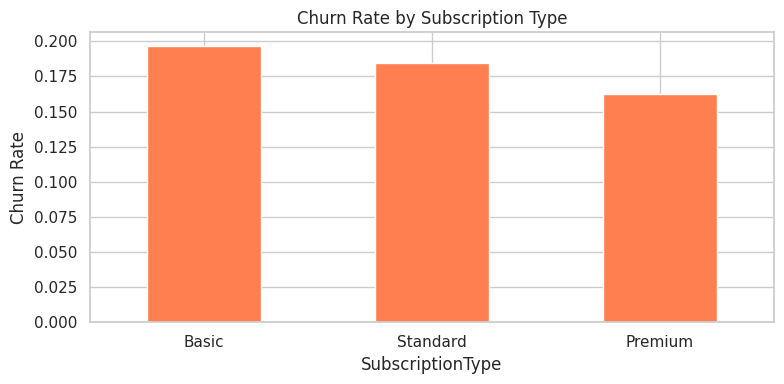

In [7]:
# Churn rate by subscription type
churn_by_sub = df.groupby('SubscriptionType')['Churn'].mean().sort_values(ascending=False)
churn_by_sub.plot(kind='bar', color='coral', figsize=(8, 4))
plt.title('Churn Rate by Subscription Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- Basic subscribers churn at 19.7% vs 16.3% for Premium - customers on the cheapest plan are most at risk. This makes business sense: they have the least invested in the service.

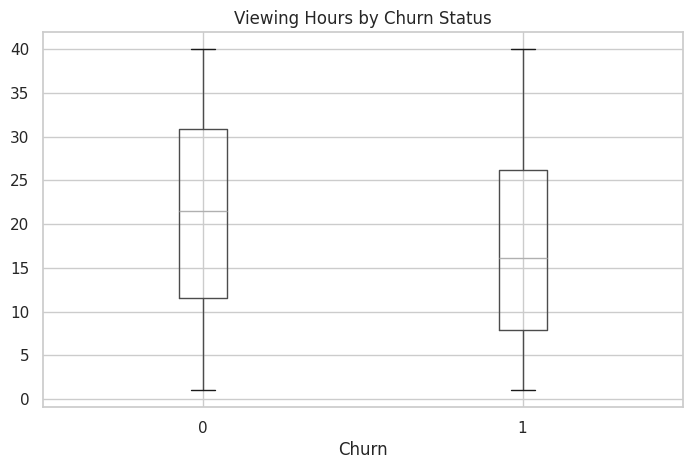

Churn
0    21.18
1    17.43
Name: ViewingHoursPerWeek, dtype: float64


In [8]:
# Do churners watch less content?
df.boxplot(column='ViewingHoursPerWeek', by='Churn', figsize=(8, 5))
plt.title('Viewing Hours by Churn Status')
plt.suptitle('')
plt.show()

print(df.groupby('Churn')['ViewingHoursPerWeek'].mean().round(2))

- Churners watch an average of 17.4 hours per week vs 21.2 hours for retained customers. Low engagement is almost always a leading indicator of churn - if a customer stops watching, they are thinking about cancelling. That gives you a window to intervene before they do.

In [9]:
# Account age comparison
print(df.groupby('Churn')['AccountAge'].mean().round(2))

Churn
0    63.27
1    45.67
Name: AccountAge, dtype: float64


## Step 3 - Prepare the data

In [10]:
# Drop CustomerID — it is just an identifier
df = df.drop('CustomerID', axis=1)

# Encode categorical columns
cat_cols = ['SubscriptionType', 'PaymentMethod', 'ContentType',
            'GenrePreference', 'DeviceRegistered', 'Gender',
            'PaperlessBilling', 'MultiDeviceAccess',
            'ParentalControl', 'SubtitlesEnabled']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# This dataset contains no missing values so no additional cleaning is required
# but it is good practice to always check
if df.isnull().sum().sum() > 0:
    df = df.dropna()

print(df.shape)

(243787, 20)


## Step 4 - Build the model

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1       # use all CPU cores
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # churn probability per customer

## Step 5 - Evaluate properly

              precision    recall  f1-score   support

      Stayed       0.83      0.99      0.90     39921
     Churned       0.56      0.05      0.10      8837

    accuracy                           0.82     48758
   macro avg       0.69      0.52      0.50     48758
weighted avg       0.78      0.82      0.76     48758



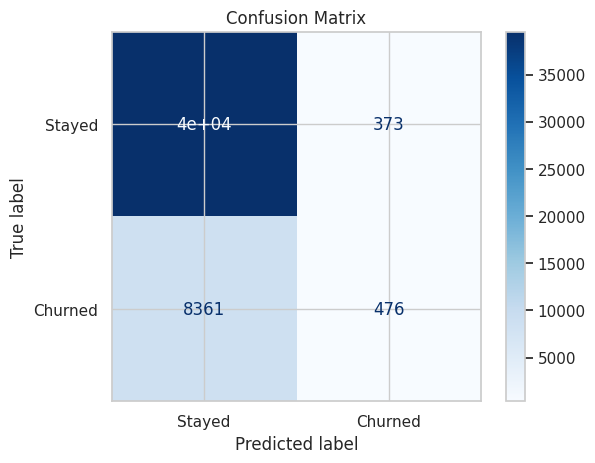

In [12]:
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## Step 6 - The business layer: revenue at risk

In [13]:
# Build a results dataframe for the test set
results = X_test.copy()
results['Churn_Actual'] = y_test.values
results['Churn_Probability'] = y_prob
results['MonthlyRevenue'] = results['MonthlyCharges']

# Expected monthly revenue at risk = probability of churn × monthly revenue
results['RevenueAtRisk'] = results['Churn_Probability'] * results['MonthlyRevenue']

# Sort by revenue at risk — highest priority first
results = results.sort_values('RevenueAtRisk', ascending=False)

# Total revenue at risk
total_at_risk = results['RevenueAtRisk'].sum()
print(f"Total monthly revenue at risk: ${total_at_risk:,.0f}")

# Top 20 customers to contact first
top_20 = results[['Churn_Probability', 'MonthlyRevenue', 'RevenueAtRisk']].head(20)
print(top_20)

Total monthly revenue at risk: $113,644
        Churn_Probability  MonthlyRevenue  RevenueAtRisk
63497                0.77       18.913941      14.563735
72293                0.72       19.333953      13.920446
75135                0.80       17.035342      13.628274
214378               0.75       17.379218      13.034414
154181               0.69       18.890121      13.034184
24965                0.67       19.421802      13.012607
151503               0.67       19.360451      12.971502
61647                0.69       18.700085      12.903059
100676               0.67       19.126948      12.815055
233334               0.67       19.059737      12.770024
193957               0.67       19.050494      12.763831
149899               0.66       19.310372      12.744845
188606               0.66       19.174018      12.654852
11568                0.69       18.339739      12.654420
123793               0.67       18.798795      12.595193
15615                0.66       19.002333      1

## Step 7 - Feature importance

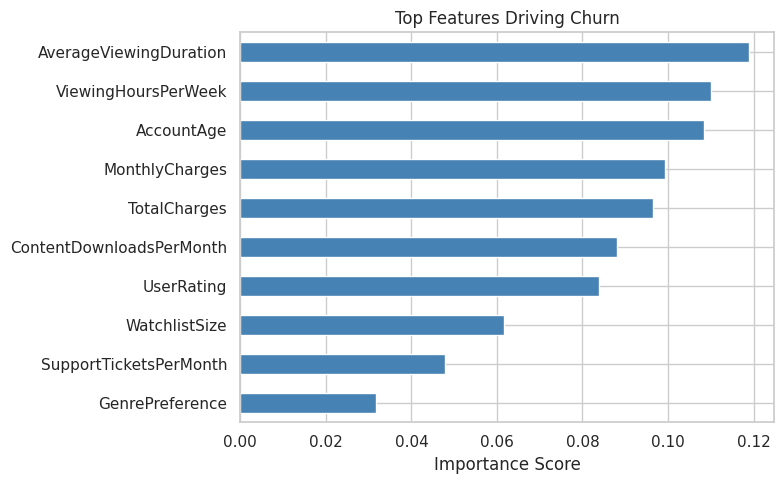

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Top Features Driving Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()